In [235]:
#Importando bibliotecas nescessarias
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Carregamento e Transformação Inicial dos Dados

Para que um algoritmo de Regressão Logística funcione, ele precisa de matrizes puramente numéricas. O objetivo deste bloco é carregar os dados brutos e traduzir as primeiras informações de texto para números.

**O que está sendo feito:**
1.  **Leitura dos Dados:** Importamos as bases de treino (onde o modelo vai aprender) e de teste (onde faremos as previsões finais).
2.  **Mapeamento da Variável Sexo:** Como a regressão calcula "pesos" matemáticos, transformamos o texto em uma variável binária (`0` para homens, `1` para mulheres).
3.  **Variáveis Dummy para o Embarque:** A coluna `Embarked` indica o portão (C, Q, S). Se usássemos números simples (1, 2, 3), o modelo poderia achar falsamente que o portão 3 vale "mais" que o portão 1. Usamos `pd.get_dummies` para criar colunas independentes de Verdadeiro/Falso para cada porto. Ocultamos a primeira coluna gerada (`drop_first=True`) porque se o passageiro não embarcou nos portões Q ou S, a matemática deduz obrigatoriamente que ele embarcou em C, evitando redundância na matriz.

In [236]:
#Carregando os dados
treino = pd.read_csv(r"csv/train.csv")
teste = pd.read_csv(r"csv/test.csv")

print("Colunas")
print("-----------------------------------------")
print(treino.columns)
print(teste.columns)
print("-----------------------------------------")
#Organizacao inicial dos dados

#Alterando colunas para valores numericos
treino["Sex"] = treino["Sex"].map({
    "male": 0,
    "female": 1,
})
teste["Sex"] = teste["Sex"].map({
    "male": 0,
    "female": 1,
})

treino = pd.get_dummies(treino, columns=["Embarked"], drop_first=True)
teste = pd.get_dummies(teste, columns=["Embarked"], drop_first=True)

treino.head()

Colunas
-----------------------------------------
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')
Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')
-----------------------------------------


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,False,True


## 2. Inspeção de Dados Ausentes e Análise de Idades

Algoritmos de Machine Learning não sabem lidar com "espaços em branco" (dados nulos ou `NaN`). O objetivo deste bloco é diagnosticar quais informações estão faltando na nossa base e decidir, de forma analítica, como preencher essas lacunas.

**O que está sendo feito:**
1.  **Mapeamento de Valores Nulos:** Utilizamos o comando `isna().sum()` para verificar onde estão os buracos nos nossos dados. Descobrimos que a coluna `Age` (Idade) possui 177 valores nulos e a coluna `Cabin` possui 687.
2.  **Validação Lógica para Preenchimento:** Uma solução preguiçosa seria preencher as idades desconhecidas simplesmente com o número `0`. Para testar se isso faz sentido na realidade do Titanic, filtramos a base buscando passageiros com idade menor que 1 (`treino['Age'] < 1`).
3.  **Conclusão da Regra de Negócio:** O retorno do nosso filtro prova que existem bebês a bordo cujas idades estão registradas em frações de ano (como 0.83 ou 0.75). Se preenchermos os 177 valores nulos com `0`, vamos poluir a matemática do modelo, forçando-o a interpretar erroneamente que centenas de adultos sem idade registrada são, na verdade, recém-nascidos. Isso nos obriga a buscar uma estratégia estatística mais inteligente (como usar a média ou a mediana) para preencher a coluna `Age` nos próximos passos.

In [237]:
print("Verificando valores nulos")
print("-----------------------------------------")
print(treino.isna().sum())
print("-----------------------------------------")

treino[treino['Age'] < 1]

Verificando valores nulos
-----------------------------------------
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked_Q       0
Embarked_S       0
dtype: int64
-----------------------------------------


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
78,79,1,2,"Caldwell, Master. Alden Gates",0,0.83,0,2,248738,29.0000,NaN,False,True
305,306,1,1,"Allison, Master. Hudson Trevor",0,0.92,1,2,113781,151.5500,C22 C26,False,True
469,470,1,3,"Baclini, Miss. Helene Barbara",1,0.75,2,1,2666,19.2583,NaN,False,False
644,645,1,3,"Baclini, Miss. Eugenie",1,0.75,2,1,2666,19.2583,NaN,False,False
755,756,1,2,"Hamalainen, Master. Viljo",0,0.67,1,1,250649,14.5000,NaN,False,True
803,804,1,3,"Thomas, Master. Assad Alexander",0,0.42,0,1,2625,8.5167,NaN,False,False
831,832,1,2,"Richards, Master. George Sibley",0,0.83,1,1,29106,18.7500,NaN,False,True


## 3. Imputação de Dados Ausentes: Tratando as Idades

Como concluímos no passo anterior, preencher as idades desconhecidas com o número `0` distorceria a nossa base e criaria "falsos bebês". A abordagem estatisticamente mais robusta para não prejudicar a distribuição do modelo é substituir esses valores nulos pela **mediana** das idades.

**O que está sendo feito:**
1.  **Cálculo da Mediana e Prevenção de Data Leakage:** Nós calculamos a mediana da idade utilizando **exclusivamente a base de treino**. Essa é uma regra fundamental: não podemos usar nenhuma informação do conjunto de teste para tomar decisões, senão estaríamos "vazando" informações do futuro para o nosso modelo e criando uma falsa sensação de precisão.
2.  **Preenchimento (Imputação):** Utilizamos o método `.fillna()` para substituir os espaços vazios (`NaN`). Aplicamos essa mesma mediana calculada no treino para preencher tanto os buracos da base de treino quanto os da base de teste, garantindo que ambas utilizem exatamente a mesma régua matemática.

In [238]:
# 1. Calculamos a mediana usando apenas o conjunto de treinamento
mediana_idade = treino['Age'].median()

# 2. Preenchemos os valores nulos em ambos os conjuntos
treino['Age'] = treino['Age'].fillna(mediana_idade)
teste['Age'] = teste['Age'].fillna(mediana_idade)

## 4. Definição das Variáveis de Treino (X) e Alvo (y)

Chegamos à última etapa de organização antes de fatiarmos os dados para o algoritmo matemático. Precisamos separar claramente o que são as nossas características de estudo (matriz `X`) e o que é o nosso gabarito (vetor `y`), além de limpar qualquer "ruído" que possa confundir a regressão.

**O que está sendo feito:**
1.  **Preservação dos IDs para o Kaggle:** Salvamos a coluna `PassengerId` em variáveis separadas (`id_treino` e `id_teste`). O modelo não deve tentar aprender padrões usando um número de identificação aleatório, mas precisaremos desses IDs intactos lá no final para construir o arquivo `.csv` de submissão do Kaggle.
2.  **Remoção de Colunas Irrelevantes (Drop):** Descartamos colunas que atrapalhariam a matemática de um modelo linear puro:
    *   `Name` e `Ticket`: São dados textuais de alta cardinalidade (muitos valores únicos). Sem técnicas avançadas de processamento de texto (NLP), elas apenas confundiriam o modelo.
    *   `Cabin`: Como diagnosticamos anteriormente, essa coluna tem uma quantidade excessiva de valores nulos (687), tornando-a inviável para este modelo *baseline*.
    *   `Survived`: Nós a removemos de `X_treino` pois ela é a resposta que queremos prever.
3.  **Separação do Alvo (Target):** Guardamos o gabarito de sobrevivência na variável `y_treino`. Ao final desta execução, nossa matriz `X_treino` será um conjunto de dados 100% numérico, padronizado e pronto para alimentar o classificador.

In [239]:
#Armazenando os ids para envio no kaggle competition
id_treino = treino["PassengerId"]
id_teste = teste["PassengerId"]

#Excluindo colunas irrelevantes para o proposito
X_treino = treino.drop(columns=["Name", "Survived","PassengerId","Ticket","Cabin"])
X_teste = teste.drop(columns=["Name", "PassengerId","Ticket","Cabin"])

#Armazenando o alvo
y_treino = treino["Survived"]

X_treino.head()


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,3,0,22.0,1,0,7.2500,False,True
1,1,1,38.0,1,0,71.2833,False,False
2,3,1,26.0,0,0,7.9250,False,True
3,1,1,35.0,1,0,53.1000,False,True
4,3,0,35.0,0,0,8.0500,False,True


## 5. Análise Exploratória de Dados (EDA): Dinâmicas Familiares

Antes de treinarmos nosso algoritmo matemático, é fundamental entendermos o comportamento dos dados através da Análise Exploratória (EDA). O objetivo deste bloco é investigar visualmente se as relações familiares a bordo influenciaram as chances de sobrevivência.

**Analisando o Gráfico 1: Irmãos e Cônjuges (`SibSp`)**

*   **Motivo da Análise:** Precisamos descobrir se a quantidade de irmãos ou cônjuges possui uma correlação linear direta com a sobrevivência (ou seja, "quanto maior o número, maior a chance") ou se existe um padrão mais complexo escondido nos números.
*   **Conclusões:** O gráfico revela um comportamento **não linear** muito claro em relação à sobrevivência:
    *   **Sozinhos (`0`):** Passageiros viajando sem irmãos ou cônjuges tiveram uma taxa de sobrevivência de base mais baixa, próxima a 34%.
    *   **Pequenos Grupos (`1` e `2`):** Estar acompanhado de 1 ou 2 familiares aumentou drasticamente as chances de sobrevivência, fazendo a taxa saltar para mais de 50%.
    *   **Grandes Famílias (`3+`):** A partir de 3 irmãos/cônjuges, a taxa de sobrevivência despenca vertiginosamente.
    
**O que isso significa para o modelo?**
Essa percepção visual prova que a variável `SibSp` não atua de forma constante. Isso nos dá embasamento analítico para, futuramente, aplicarmos técnicas de Engenharia de Características (Feature Engineering), agrupando essas pessoas em categorias ("Sozinhos", "Família Pequena", "Família Grande") para ajudar o modelo linear a capturar esse "sobe e desce" da probabilidade.

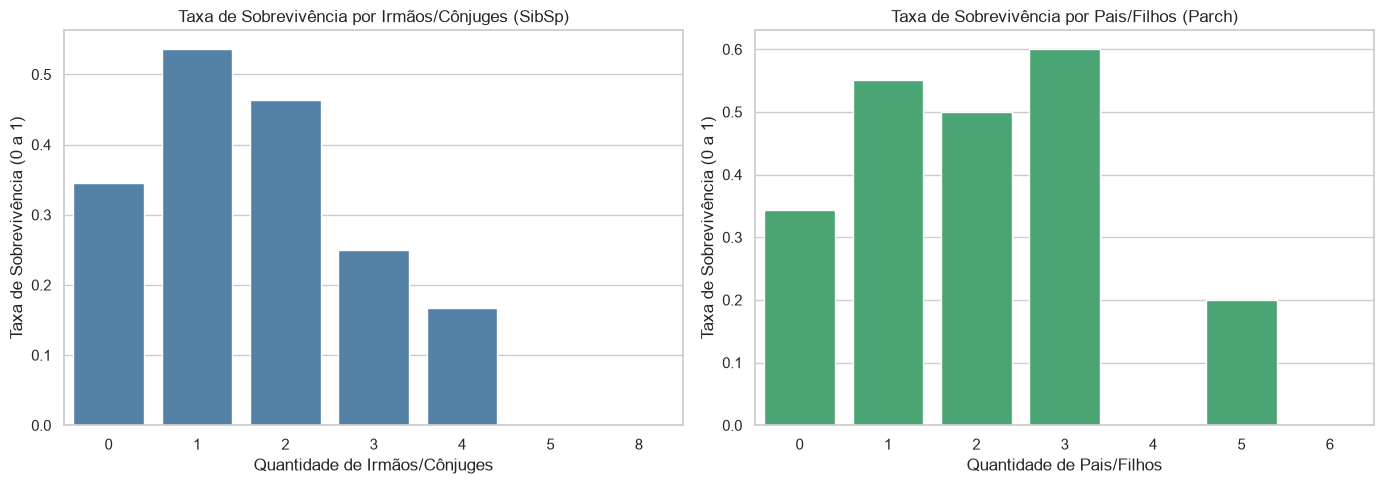

In [240]:
#EDA

# Configura o estilo visual dos gráficos
sns.set_theme(style="whitegrid")

# Cria uma figura com dois espaços (1 linha, 2 colunas)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Impacto da variável SibSp
sns.barplot(data=treino, x='SibSp', y='Survived', ax=axes[0], color='steelblue', errorbar=None)
axes[0].set_title('Taxa de Sobrevivência por Irmãos/Cônjuges (SibSp)')
axes[0].set_ylabel('Taxa de Sobrevivência (0 a 1)')
axes[0].set_xlabel('Quantidade de Irmãos/Cônjuges')

# Gráfico 2: Impacto da variável Parch
sns.barplot(data=treino, x='Parch', y='Survived', ax=axes[1], color='mediumseagreen', errorbar=None)
axes[1].set_title('Taxa de Sobrevivência por Pais/Filhos (Parch)')
axes[1].set_ylabel('Taxa de Sobrevivência (0 a 1)')
axes[1].set_xlabel('Quantidade de Pais/Filhos')

# Ajusta o layout para não sobrepor os textos e exibe
plt.tight_layout()
plt.show()

## 6. Análise Exploratória de Dados (EDA): Distribuição de Tarifas por Classe

Avançando na nossa exploração visual, agora investigamos a variável `Fare` (tarifa paga) em relação à classe do bilhete (`Pclass`) e à sobrevivência. Para isso, optamos por um **Boxplot**, uma ferramenta estatística excelente para visualizar medianas, dispersão de dados e identificar valores atípicos (*outliers*).

**O que está sendo feito e analisado:**
1.  **Ajuste de Escala (Tratamento Visual):** Limitamos o eixo Y a 200 dólares utilizando `plt.ylim`. Fizemos isso porque a 1ª classe possui *outliers* extremos (bilhetes que custaram mais de 500 dólares), o que "esmagava" a visualização das classes inferiores no gráfico original.
2.  **O Comportamento na 1ª Classe:** A principal descoberta visual está na classe 1. A caixa laranja (sobreviventes) possui uma mediana e um limite superior visivelmente mais altos do que a caixa verde (não sobreviventes). Isso indica que, mesmo dentro da elite do navio, os passageiros que pagaram passagens mais caras tiveram maiores chances de sobrevivência.
3.  **Comportamento nas Classes 2 e 3:** Nas demais classes, o valor da tarifa parece não ter sido um grande diferencial para a sobrevivência, já que as caixas verdes e laranjas estão praticamente alinhadas. Contudo, notamos uma densidade alta de *outliers* na 3ª classe, o que provavelmente reflete tarifas de grupos familiares compradas em conjunto.

**Impacto para o Modelo:**
Esta visualização comprova que a coluna `Fare` possui uma variância altíssima e *outliers* significativos. Como modelos lineares (como a Regressão Logística que vamos utilizar) são muito sensíveis à escala, isso confirma a necessidade estrita de aplicarmos um padronizador de escala (como o `StandardScaler`) na nossa *pipeline* antes do treinamento, garantindo que essa variável não domine o modelo injustamente.

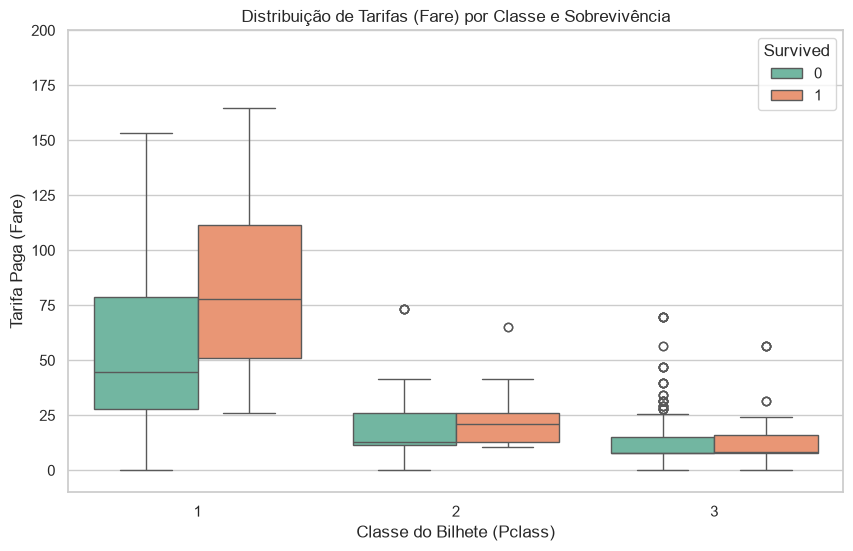

In [241]:
# Configura o estilo
sns.set_theme(style="whitegrid")

# Cria a figura
plt.figure(figsize=(10, 6))

# Gera o boxplot agrupando por Classe e quebrando a cor pela Sobrevivência
sns.boxplot(data=treino, x='Pclass', y='Fare', hue='Survived', palette='Set2')

plt.title('Distribuição de Tarifas (Fare) por Classe e Sobrevivência')
plt.xlabel('Classe do Bilhete (Pclass)')
plt.ylabel('Tarifa Paga (Fare)')

# Limitamos o eixo Y em 200 para facilitar a visualização, 
# já que a 1ª classe tem alguns outliers extremos que pagaram mais de 500 dólares
plt.ylim(-10, 200)

plt.show()

## 7. Divisão de Treino e Validação Local (Holdout)

Com os nossos dados limpos e as variáveis alvo definidas, precisamos de uma forma de avaliar a performance do nosso modelo matematicamente antes de gerar o arquivo final de submissão. Como não possuímos o gabarito de sobrevivência da base de teste oficial fornecida pelo Kaggle, criamos o nosso próprio ambiente de teste isolado.

**O que está sendo feito:**
1.  **Separação dos Dados (`train_test_split`):** Utilizamos a técnica de *Holdout*, fatiando a nossa matriz e vetor originais em duas partes. Destinamos 80% dos dados para o ambiente de treino (`X_treino_local`, `y_treino_local`), onde o algoritmo estudará as relações entre as características e a sobrevivência.
2.  **Base de Validação (20%):** Os 20% restantes (`X_val_local`, `y_val_local`) são estritamente "escondidos" do modelo durante a fase de aprendizado. Eles servirão como uma prova final para calcularmos a nossa precisão (acurácia) em dados inéditos.
3.  **Reprodutibilidade (`random_state=42`):** Fixamos a semente aleatória matemática. Essa é uma prática fundamental para garantir que, toda vez que executarmos este *notebook*, o corte seja feito exatamente nos mesmos passageiros. Isso nos permite ter um controle rigoroso caso decidamos testar novos algoritmos futuramente (como Random Forest, por exemplo), garantindo que as comparações de desempenho sejam justas.

In [242]:
# 1. Fatiando os dados: 80% para treino real e 20% para validação local
# O random_state=42 garante que o corte seja idêntico toda vez que você rodar o código
X_treino_local, X_val_local, y_treino_local, y_val_local = train_test_split(
    X_treino, y_treino, test_size=0.2, random_state=42
)

## 8. Padronização de Escala (Feature Scaling)

Como identificamos na nossa Análise Exploratória (quando analisamos a distribuição das tarifas por classe), variáveis como a `Fare` possuem uma amplitude muito maior do que variáveis ordinais como `Pclass` ou `SibSp`. Algoritmos lineares (como a Regressão Logística que adotamos) são extremamente sensíveis a essas discrepâncias de grandeza. Para evitar que variáveis com números maiores "dominem" as decisões matemáticas do modelo de forma injusta, aplicamos a padronização.

**O que está sendo feito:**
1.  **Inicialização do Escalonador:** Instanciamos o `StandardScaler`, que transformará nossos dados para que tenham uma média igual a zero e um desvio padrão igual a um.
2.  **Ajuste e Transformação no Treino (`fit_transform`):** Aplicamos este método na nossa matriz de treino. Aqui, o algoritmo "aprende" a média e a variância exclusivas desta base e, em seguida, aplica a transformação.
3.  **Prevenção de Data Leakage na Validação (`transform`):** Mais uma vez, aplicamos a regra fundamental de isolamento. Usamos **apenas** o `.transform()` na base de validação (`X_val_local`). Isso garante que a base de teste seja ajustada usando a "régua" aprendida estritamente com os dados de treino, sem vazar nenhuma informação estatística do conjunto de teste para o nosso modelo.

In [243]:
#Padronizando a escala dos dados
scaler = StandardScaler()
X_treino_norm = scaler.fit_transform(X_treino_local)
X_val_local = scaler.transform(X_val_local)

## 9. Treinamento do Modelo e Interpretação dos Coeficientes

Com os nossos dados devidamente padronizados e separados, instanciamos e treinamos o nosso modelo base de Regressão Logística (`LogisticRegression`). Uma das grandes vantagens da escolha deste algoritmo estatístico clássico é a sua transparência: ele nos permite extrair os "pesos" (coeficientes) que atribuiu a cada variável, revelando exatamente a lógica matemática que utilizará para prever quem sobreviveu ou não.

**Analisando a Importância das Variáveis (Coeficientes):**
*   **Forte Impacto Positivo:** A variável `Sex` possui, de longe, o maior peso positivo do modelo (1.27). Isso confirma matematicamente o forte viés de resgate para o sexo feminino (a histórica diretriz de "mulheres e crianças primeiro"). 
*   **Forte Impacto Negativo:** A classe do bilhete (`Pclass`) é o fator que mais puxa a probabilidade de sobrevivência para baixo (-0.78). Como as classes são numeradas de 1 a 3, a matemática do modelo capturou que quanto maior esse número (ex: 3ª classe), menores eram as chances. A idade (`Age`) e a quantidade de irmãos/cônjuges (`SibSp`) também são fortes preditores negativos.
*   **Impacto Marginal:** Fatores como a tarifa (`Fare`) e os portos de embarque (`Embarked_Q`, `Embarked_S`) apresentaram coeficientes mais próximos de zero, indicando que, na presença das demais variáveis estruturais (como sexo e classe), o local de embarque pouco influenciou no destino final do passageiro segundo o nosso modelo linear.

In [244]:
#Implementando o modelo de regressao logistica
modelo = LogisticRegression().fit(X_treino_norm, y_treino_local)
colunas_treinadas = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked_Q','Embarked_S']

# Criando uma tabela para visualizar a importância de cada variável
importancia_features = pd.DataFrame({
    'Feature': colunas_treinadas,
    'Peso (Coeficiente)': modelo.coef_[0]
}).sort_values(by='Peso (Coeficiente)', ascending=False)

display(importancia_features)

,Feature,Peso (Coeficiente)
1,Sex,1.275700
5,Fare,0.124587
6,Embarked_Q,-0.049019
4,Parch,-0.095401
7,Embarked_S,-0.196196
3,SibSp,-0.348851
2,Age,-0.396919
0,Pclass,-0.784441


## 10. Avaliação do Modelo e Decisões de Engenharia de Atributos (Feature Engineering)

Chegou o momento de testarmos a eficácia prática da nossa Regressão Logística. Utilizamos a base de validação (`X_val_local`), que mantivemos estritamente isolada durante o treinamento, para gerar previsões e compará-las com o gabarito real (`y_val_local`).

**Resultados e Tomada de Decisão:**
*   **Acurácia Atingida:** Nosso modelo obteve uma precisão de **81.01%** na previsão de sobrevivência em dados não vistos. Este é um resultado bastante sólido e confiável para um modelo *baseline* linear puro.
*   **A Tentativa com "Tamanho da Família":** É fundamental registrar que realizamos experimentos paralelos de *Feature Engineering*. Baseando-nos nos insights da nossa Análise Exploratória (EDA), tentamos modelar uma nova variável que unificava `SibSp` e `Parch` em um único atributo de "Tamanho da Família" (*Family Size*).
*   **Por que descartamos a nova feature?** Embora a criação desse agrupamento fizesse total sentido lógico e humano, a validação matemática nos mostrou o oposto: ao aplicarmos essa transformação, a eficácia do modelo **caiu para 78%**. 

**Conclusão:**
Essa queda de performance indica que, para este algoritmo específico, a granularidade dos dados originais importa. A Regressão Logística consegue extrair mais valor sabendo exatamente se o acompanhante é um irmão/cônjuge ou um pai/filho de forma separada, do que apenas sabendo o tamanho total do grupo. Portanto, pelo princípio da navalha de Occam, optamos por descartar a *feature* complexa, mantendo a simplicidade das variáveis originais e garantindo a nossa marca superior a 81%.

In [245]:
previsoes_val = modelo.predict(X_val_local)
acuracia = accuracy_score(y_val_local, previsoes_val)
print(f"Acurácia de Validação: {acuracia * 100:.2f}%")

Acurácia de Validação: 81.01%


## 11. Retreinamento com Dataset Completo e Submissão

Após validarmos as nossas escolhas de Engenharia de Atributos (descartando *features* que pioravam o modelo) e confirmarmos a nossa acurácia através do ambiente de validação local (20% dos dados), chegamos à etapa final. 

**O que está sendo feito:**
1.  **Reaproveitamento de Dados:** Como as decisões de modelagem já estão tomadas, não há mais necessidade de reter os 20% da base de validação. Para maximizar a capacidade de generalização do modelo, nós o retreinamos utilizando **100% dos dados de treino originais** disponíveis.
2.  **Padronização Final:** Instanciamos um novo `StandardScaler` e o ajustamos (`fit_transform`) à totalidade da matriz `X_treino`. Em seguida, aplicamos essa mesma transformação geométrica (`transform`) à base `X_teste` fornecida pelo Kaggle.
3.  **Previsão e Exportação:** O modelo final analisa a base de teste cega e gera as estimativas de sobrevivência. Unimos essas previsões com a coluna `PassengerId` e exportamos o resultado em um arquivo `.csv` sem índice, exatamente no formato exigido para a pontuação na plataforma.

In [246]:
# 0. Tratamento de Valores Nulos (NaN) na base de teste
# Preenchemos os vazios do teste usando a mediana encontrada nos dados de treino
X_teste = X_teste.fillna(X_treino.median())

# 1. Padronização: Ajustamos e transformamos 100% dos dados de treino originais
scaler_final = StandardScaler()
X_treino_full_norm = scaler_final.fit_transform(X_treino)

# Transformamos os dados do Kaggle com a mesma régua
X_teste_norm = scaler_final.transform(X_teste)

# 2. Retreinamento: Treinamos o modelo com todos os dados e o gabarito original
modelo_final = LogisticRegression().fit(X_treino_full_norm, y_treino)

# 3. Gerando as previsões finais
previsoes_finais = modelo_final.predict(X_teste_norm)

# 4. Criando o DataFrame no formato exigido pelo Kaggle
submissao = pd.DataFrame({
    "PassengerId": id_teste,
    "Survived": previsoes_finais
})

# 5. Exportando para CSV
submissao.to_csv("submissao_titanic.csv", index=False)

print("Tratamento de NaNs realizado, retreinamento concluído e arquivo salvo com sucesso!")
submissao.head()

Tratamento de NaNs realizado, retreinamento concluído e arquivo salvo com sucesso!


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
